<a href="https://colab.research.google.com/github/Nhulan0208/NhuLan/blob/main/DataTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇻🇳 Vietnamese Image Captioning

| Bước | Nội dung |
|---|---|
| 1 | Cài đặt & Import |
| 2 | Upload JSON + Tải ảnh song song |
| 3 | EDA — Phân tích dữ liệu |
| 4 | Tiền xử lý + Cân bằng class |
| 5 | Xây dựng model ViT-B/16 |
| 6 | Huấn luyện + Early Stopping |
| 7 | Xuất model sang file `.pth` |

## 📦 0. Cài đặt
📦 Cài thư viện cần cho project (torch, nltk, matplotlib, …)

📥 Tải dữ liệu NLTK (tokenize, wordnet)

🔇 %%capture để ẩn log cài đặt cho gọn notebook

✅ In xác nhận đã cài xong

In [ ]:
%%capture
!pip install torch torchvision
!pip install nltk matplotlib seaborn wordcloud tqdm Pillow
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('✅ Cài đặt xong')

In [ ]:
import json, os, re, math, time, random, collections, pickle, warnings
import urllib.request, threading, io, base64
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from wordcloud import WordCloud
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# ── Seed ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Đường dẫn quan trọng ────────────────────────────────────
IMAGE_DIR   = Path('uitviic_images')
CKPT_PATH   = Path('checkpoint.pth')    # checkpoint sau mỗi epoch
BEST_PATH   = Path('best_model.pth')    # best val loss
EXPORT_PATH = Path('vicaptioning_full.pth')  # file cuối cùng để dùng HTML
IMAGE_DIR.mkdir(exist_ok=True)
print(f'   Checkpoint: {CKPT_PATH}')
print(f'   Best model: {BEST_PATH}')

✅ Device : cpu
   Checkpoint: checkpoint.pth
   Best model: best_model.pth


---
## 1️⃣ Thu thập dữ liệu
### 1a. Upload 3 file JSON lên Colab

In [ ]:
import json
import os

# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
# Giải quyết lỗi NameError bằng cách kiểm tra môi trường chạy
try:
    # Nếu chạy từ file .py (Script)
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Nếu chạy từ file .ipynb hoặc Console (Interactive)
    BASE_DIR = os.getcwd()

# Định nghĩa tên các file cần đọc theo đúng file bạn đang có
FILE_NAMES = {
    "test": "uitviic_captions_test2017.json",
    "train_data": "uitviic_captions_train2017.json", # Đã sửa theo tên trong ảnh của bạn
    "val_data": "uitviic_captions_val2017.json"     # Đã sửa theo tên trong ảnh của bạn
}

def load_json_files():
    """
    Hàm đọc các file JSON từ thư mục local
    """
    data = {}
    print(f'💻 Thư mục làm việc hiện tại: {BASE_DIR}')

    for key, filename in FILE_NAMES.items():
        file_path = os.path.join(BASE_DIR, filename)

        if os.path.exists(file_path):
            try:
                # encoding='utf-8' quan trọng để đọc tiếng Việt chuẩn
                with open(file_path, 'r', encoding='utf-8') as f:
                    data[key] = json.load(f)
                print(f"✅ Đã nạp thành công: {filename}")
            except Exception as e:
                print(f"❌ LỖI khi đọc file {filename}: {e}")
        else:
            print(f"❌ LỖI: Không tìm thấy file '{filename}' tại {file_path}")

    return data

# --- 2. THỰC THI ---
json_data = load_json_files()



💻 Thư mục làm việc hiện tại: C:\Users\Admin\PyCharmMiscProject
✅ Đã nạp thành công: uitviic_captions_test2017.json
✅ Đã nạp thành công: uitviic_captions_train2017.json
✅ Đã nạp thành công: uitviic_captions_val2017.json


In [ ]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

train_data = load_json('uitviic_captions_train2017.json')
val_data   = load_json('uitviic_captions_val2017.json')
test_data  = load_json('uitviic_captions_test2017.json')

print(f'Train: {len(train_data["images"])} ảnh | {len(train_data["annotations"])} captions')
print(f'Val  : {len(val_data["images"])} ảnh | {len(val_data["annotations"])} captions')
print(f'Test : {len(test_data["images"])} ảnh | {len(test_data["annotations"])} captions')

Train: 2695 ảnh | 13481 captions
Val  : 924 ảnh | 4620 captions
Test : 231 ảnh | 1155 captions


### 1b. Tải ảnh song song (16 luồng — ~3 phút)

In [ ]:
# ═══════════════════════════════════════════════════════════
# ⚡ TẢI ẢNH SONG SONG — ThreadPoolExecutor 16 luồng
#    Nhanh hơn tuần tự ~10 lần (2-3 phút thay vì 20 phút)
# ═══════════════════════════════════════════════════════════

all_images = {}
for split in [train_data, val_data, test_data]:
    for img in split['images']:
        all_images[img['id']] = img

to_download = [
    img for img in all_images.values()
    if not (IMAGE_DIR / img['file_name']).exists()
]

print(f'Tổng ảnh: {len(all_images)} | Cần tải: {len(to_download)} | Đã có: {len(all_images)-len(to_download)}')

def download_one(img_info):
    save_path = IMAGE_DIR / img_info['file_name']
    if save_path.exists():
        return 'skip'
    url = img_info.get('coco_url') or img_info.get('flickr_url')
    try:
        urllib.request.urlretrieve(url, save_path)
        return 'ok'
    except:
        return 'fail'

if to_download:
    ok = skip = fail = 0
    with ThreadPoolExecutor(max_workers=16) as ex:
        futures = {ex.submit(download_one, img): img for img in to_download}
        pbar = tqdm(as_completed(futures), total=len(futures), desc='⚡ Downloading')
        for f in pbar:
            r = f.result()
            if r == 'ok':   ok   += 1
            elif r == 'skip': skip += 1
            else:           fail += 1
            pbar.set_postfix(ok=ok, fail=fail)
    print(f'\n✅ OK: {ok} | Skip: {skip} | Fail: {fail}')
else:
    print('✅ Đã có đủ ảnh!')

Tổng ảnh: 3850 | Cần tải: 0 | Đã có: 3850
✅ Đã có đủ ảnh!


---
## 2️⃣ EDA — Khám phá dữ liệu
> Mục tiêu: hiểu phân bố dataset trước khi xử lý

In [ ]:
all_captions = [a['caption'] for a in train_data['annotations']]
cap_lengths  = [len(c.split()) for c in all_captions]
all_words    = [w for c in all_captions for w in c.lower().split()]
word_freq    = Counter(all_words)

sport_kw = {'tennis':0,'bóng đá':0,'bóng rổ':0,'bóng chuyền':0,'chạy':0,'bơi':0,'xe đạp':0}
for c in all_captions:
    cl = c.lower()
    for k in sport_kw:
        if k in cl: sport_kw[k] += 1

print(f'Tổng captions (train)  : {len(all_captions)}')
print(f'Từ duy nhất            : {len(word_freq)}')
print(f'Độ dài TB              : {np.mean(cap_lengths):.2f} từ')
print(f'Min / Max              : {min(cap_lengths)} / {max(cap_lengths)}')
print(f'\n⚠️  Phân bố thể thao (mất cân bằng — cần WeightedSampler):')
for k,v in sorted(sport_kw.items(), key=lambda x:-x[1]):
    bar = '█' * int(v/len(all_captions)*50)
    print(f'  {k:<15} {v:>5} ({v/len(all_captions)*100:5.1f}%) {bar}')

Tổng captions (train)  : 13481
Từ duy nhất            : 1318
Độ dài TB              : 13.11 từ
Min / Max              : 1 / 34

⚠️  Phân bố thể thao (mất cân bằng — cần WeightedSampler):
  tennis           6225 ( 46.2%) ███████████████████████
  bóng đá           961 (  7.1%) ███
  chạy              262 (  1.9%) 
  bóng rổ           125 (  0.9%) 
  bóng chuyền        50 (  0.4%) 
  bơi                 7 (  0.1%) 
  xe đạp              6 (  0.0%) 


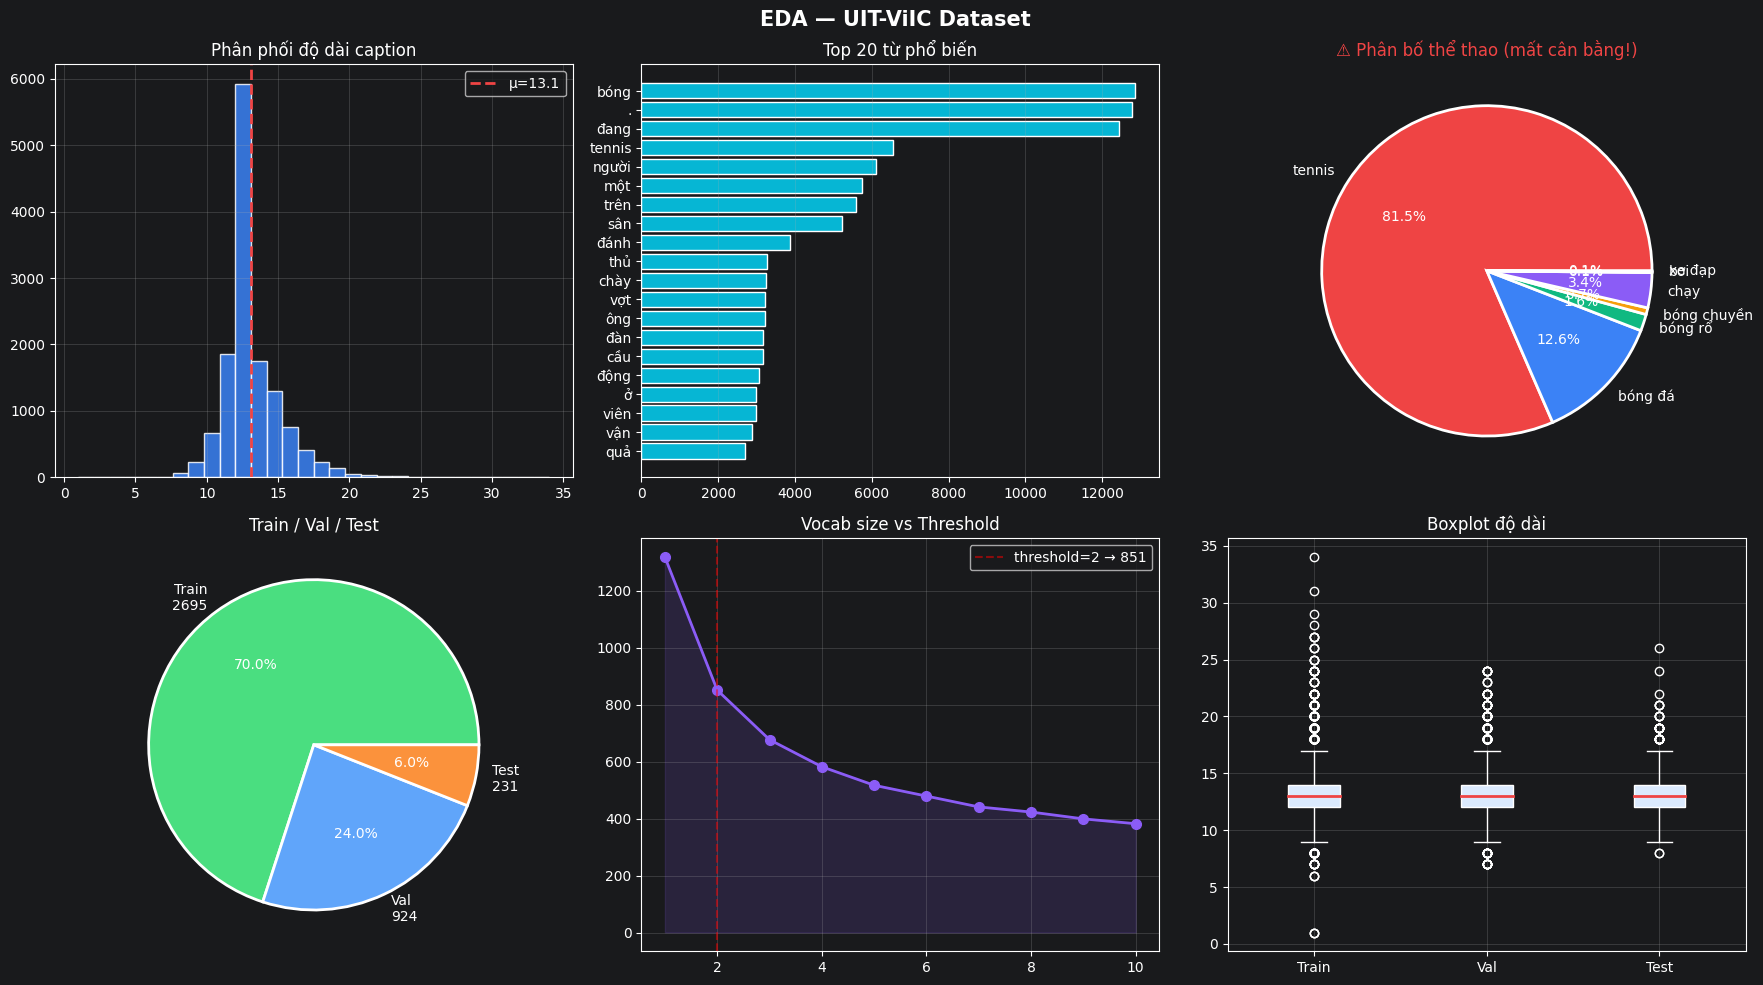

✅ Lưu eda.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — UIT-ViIC Dataset', fontsize=15, fontweight='bold')

# 1. Histogram
axes[0,0].hist(cap_lengths, bins=30, color='#3b82f6', edgecolor='white', alpha=.85)
axes[0,0].axvline(np.mean(cap_lengths), color='#ef4444', lw=2, ls='--', label=f'μ={np.mean(cap_lengths):.1f}')
axes[0,0].set_title('Phân phối độ dài caption'); axes[0,0].legend(); axes[0,0].grid(alpha=.3)

# 2. Top 20 từ
top20 = word_freq.most_common(20)
w20, c20 = zip(*top20)
axes[0,1].barh(list(w20)[::-1], list(c20)[::-1], color='#06b6d4', edgecolor='white')
axes[0,1].set_title('Top 20 từ phổ biến'); axes[0,1].grid(alpha=.3, axis='x')

# 3. Sports pie
sk = [(k,v) for k,v in sport_kw.items() if v>0]
axes[0,2].pie([v for _,v in sk], labels=[k for k,_ in sk], autopct='%1.1f%%',
              colors=['#ef4444','#3b82f6','#10b981','#f59e0b','#8b5cf6','#ec4899'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,2].set_title('⚠️ Phân bố thể thao (mất cân bằng!)', color='#ef4444')

# 4. Train/Val/Test
sz = [len(train_data['images']), len(val_data['images']), len(test_data['images'])]
axes[1,0].pie(sz, labels=[f'Train\n{sz[0]}', f'Val\n{sz[1]}', f'Test\n{sz[2]}'],
              autopct='%1.1f%%', colors=['#4ade80','#60a5fa','#fb923c'],
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,0].set_title('Train / Val / Test')

# 5. Vocab coverage
thrs = list(range(1,11))
vsz  = [sum(1 for c in word_freq.values() if c>=t) for t in thrs]
axes[1,1].plot(thrs, vsz, 'o-', color='#8b5cf6', lw=2, ms=7)
axes[1,1].fill_between(thrs, vsz, alpha=.15, color='#8b5cf6')
axes[1,1].axvline(2, color='red', ls='--', alpha=.5, label='threshold=2 → '+str(vsz[1]))
axes[1,1].set_title('Vocab size vs Threshold'); axes[1,1].legend(); axes[1,1].grid(alpha=.3)

# 6. Boxplot
val_lens  = [len(a['caption'].split()) for a in val_data['annotations']]
test_lens = [len(a['caption'].split()) for a in test_data['annotations']]
axes[1,2].boxplot([cap_lengths, val_lens, test_lens], labels=['Train','Val','Test'],
                  patch_artist=True, boxprops=dict(facecolor='#dbeafe'),
                  medianprops=dict(color='#ef4444', lw=2))
axes[1,2].set_title('Boxplot độ dài'); axes[1,2].grid(alpha=.3)

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu eda.png')

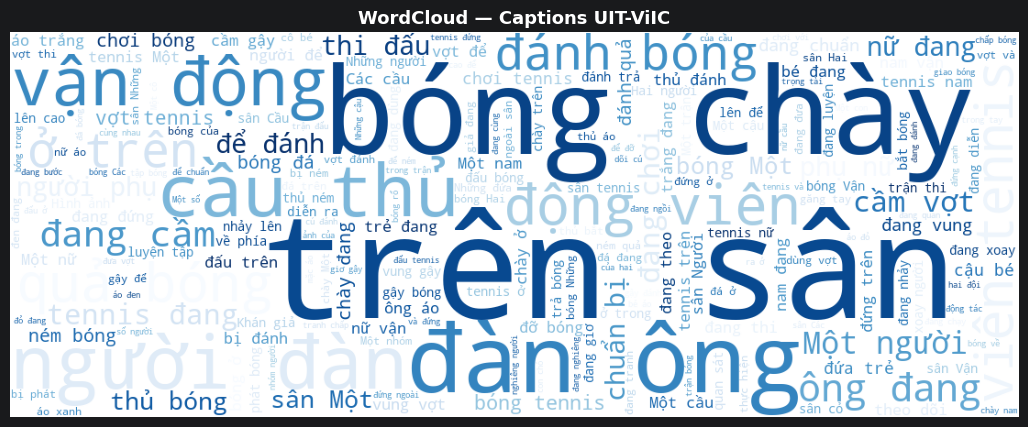

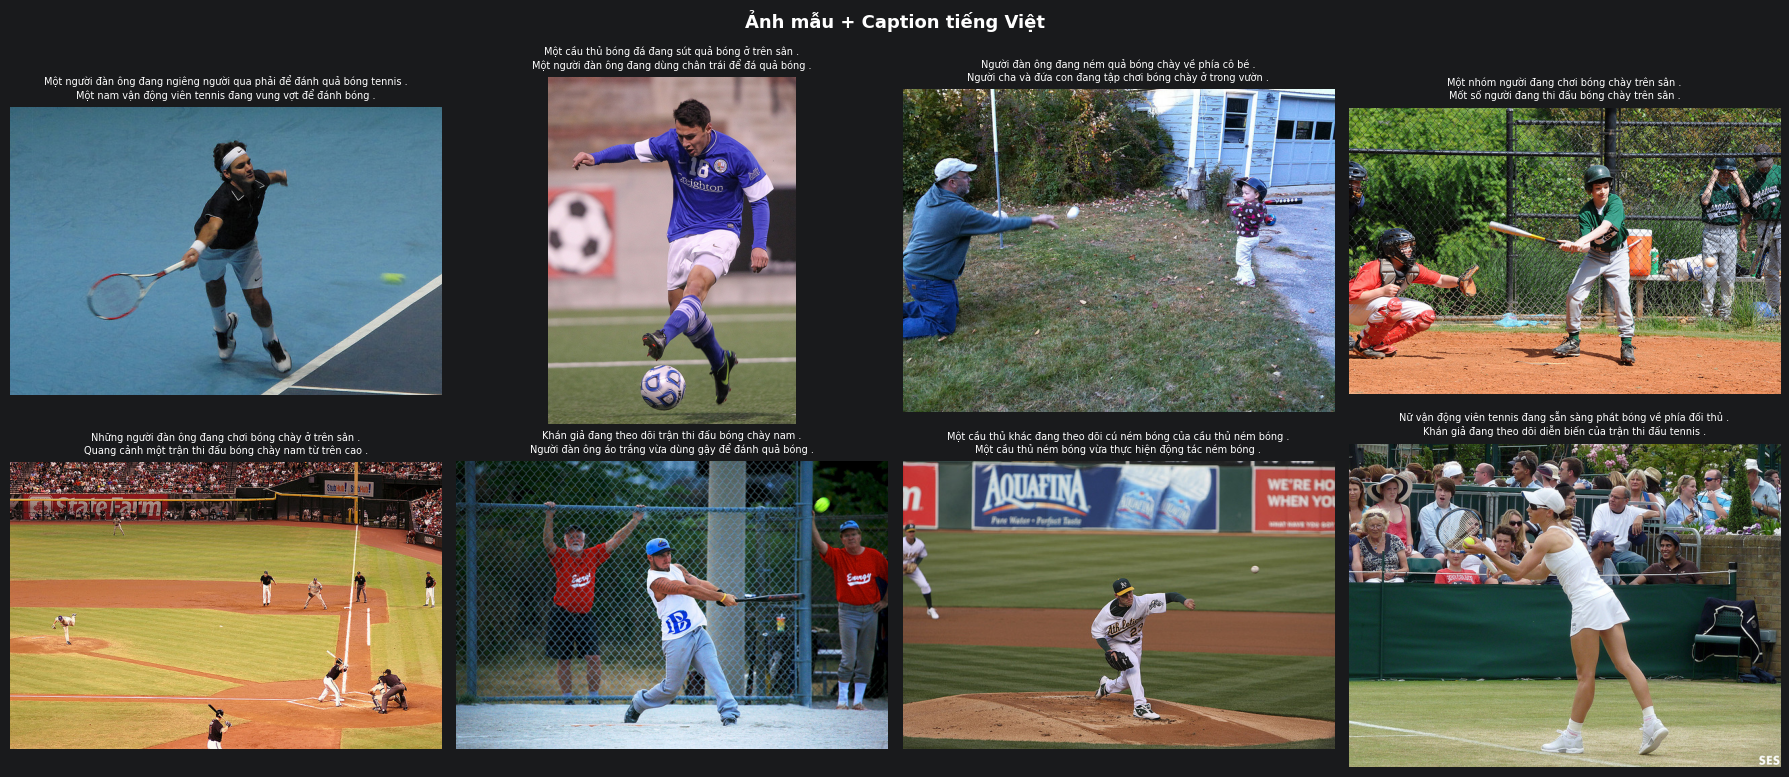

In [ ]:
# WordCloud + Ảnh mẫu
wc = WordCloud(width=1100, height=420, background_color='white', colormap='Blues', max_words=200)
wc.generate(' '.join(all_captions))
plt.figure(figsize=(14,5)); plt.imshow(wc); plt.axis('off')
plt.title('WordCloud — Captions UIT-ViIC', fontsize=13, fontweight='bold')
plt.savefig('wordcloud.png', dpi=130); plt.show()

id2caps_tr = defaultdict(list)
for ann in train_data['annotations']: id2caps_tr[ann['image_id']].append(ann['caption'])

samples = random.sample(train_data['images'], 8)
fig, axes = plt.subplots(2, 4, figsize=(18,8))
fig.suptitle('Ảnh mẫu + Caption tiếng Việt', fontsize=13, fontweight='bold')
for ax, img_info in zip(axes.flat, samples):
    p = IMAGE_DIR / img_info['file_name']
    try: ax.imshow(mpimg.imread(p))
    except: ax.set_facecolor('#ddd')
    caps = id2caps_tr.get(img_info['id'], ['?'])
    ax.set_title('\n'.join(caps[:2]), fontsize=7); ax.axis('off')
plt.tight_layout()
plt.savefig('samples.png', dpi=110); plt.show()

---
## 3️⃣ Tiền xử lý + Cân bằng dữ liệu
> **Vấn đề:** Tennis chiếm 81.5% → model bias, luôn sinh caption tennis
> **Giải pháp:** SmartSampler (sqrt-smoothing) + Caption Augmentation

In [ ]:
# ===================================================================
# TIEN XU LY + DATASET — ViT compatible
# Fix: mat can bang tennis 81.5% bang sqrt-smoothing sampler
# ===================================================================

from collections import Counter, defaultdict
from torch.utils.data import WeightedRandomSampler, Dataset, DataLoader
import random

# ── Clean caption ────────────────────────────────────────────────
def clean_caption(text):
    text = text.lower().strip()
    text = re.sub(r'[^\u00C0-\u024F\u1E00-\u1EFF\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

MAX_LEN  = 42
IMG_SIZE = 224
IS_GPU   = device.type == 'cuda'
BATCH    = 24 if IS_GPU else 8

# ── Vocabulary ───────────────────────────────────────────────────
class Vocabulary:
    PAD, SOS, EOS, UNK = 0, 1, 2, 3
    def __init__(self, freq_threshold=2):
        self.word2idx = {'<PAD>':0,'<SOS>':1,'<EOS>':2,'<UNK>':3}
        self.idx2word = {v:k for k,v in self.word2idx.items()}
        self.freq_threshold = freq_threshold
    def build(self, captions):
        freq = Counter()
        for cap in captions: freq.update(clean_caption(cap).split())
        for word, cnt in sorted(freq.items(), key=lambda x:-x[1]):
            if cnt >= self.freq_threshold:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        return self
    def encode(self, caption):
        return [self.word2idx.get(w, self.UNK) for w in clean_caption(caption).split()]
    def decode(self, indices):
        out = []
        for i in indices:
            if i in (self.SOS, self.PAD): continue
            if i == self.EOS: break
            out.append(self.idx2word.get(i, ''))
        return ' '.join(out)
    def __len__(self): return len(self.word2idx)

vocab = Vocabulary(freq_threshold=2).build([a['caption'] for a in train_data['annotations']])
print(f'Vocab: {len(vocab)} tu')


# ── Sport Classifier ─────────────────────────────────────────────
SPORT_KWS = [
    (['tennis', 'vot', 'san tennis'],                     0),
    (['bong da', 'sut', 'thu mon', 'cau thu', 'bong đa'], 1),
    (['bong ro', 'ro cau', 'nem bong', 'bong rổ'],        2),
    (['bong chuyen', 'luoi chuyen', 'bong chuyền'],        3),
    (['chay', 'chạy', 'marathon'],                         4),
    (['boi', 'bơi', 'ho boi'],                             5),
    (['xe dap', 'xe đạp', 'dap xe'],                      6),
    (['truot', 'trượt'],                                   7),
    (['bong chay', 'bong chày'],                           8),
    (['golf', 'gay golf'],                                 9),
]

def classify_caption(cap):
    cl = cap.lower()
    for kws, cls_id in SPORT_KWS:
        if any(kw in cl for kw in kws):
            return cls_id
    return 10  # other

# Phan bo hien tai
all_caps    = [a['caption'] for a in train_data['annotations']]
all_classes = [classify_caption(c) for c in all_caps]
cc          = Counter(all_classes)
total       = len(all_classes)
print('\nPhan bo du lieu:')
CLASS_NAMES = ['tennis','bong_da','bong_ro','bong_chuyen',
               'chay','boi','xe_dap','truot','bong_chay','golf','other']
for cid, name in enumerate(CLASS_NAMES):
    cnt = cc.get(cid, 0)
    bar = '█' * int(cnt/total*40)
    print(f'  {name:<14}: {cnt:>5} ({cnt/total*100:>5.1f}%) {bar}')


# ── ViICDataset ──────────────────────────────────────────────────
class ViICDataset(Dataset):
    def __init__(self, data, image_dir, vocab, transform=None,
                 max_len=42, extra_samples=None):
        self.image_dir = Path(image_dir)
        self.vocab = vocab; self.transform = transform; self.max_len = max_len
        id2fname = {img['id']: img['file_name'] for img in data['images']}
        self.samples = [(id2fname[a['image_id']], a['caption'])
                        for a in data['annotations'] if a['image_id'] in id2fname]
        if extra_samples:
            self.samples.extend(extra_samples)
            print(f'  + {len(extra_samples)} augmented samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fname, caption = self.samples[idx]
        try:    img = Image.open(self.image_dir / fname).convert('RGB')
        except: img = Image.new('RGB', (256, 256), (128, 128, 128))
        if self.transform: img = self.transform(img)
        tokens = [vocab.SOS] + vocab.encode(caption) + [vocab.EOS]
        tokens = tokens[:self.max_len]
        tokens += [vocab.PAD] * (self.max_len - len(tokens))
        return img, torch.tensor(tokens, dtype=torch.long), caption


# ── Caption Augmentation cho class thieu ─────────────────────────
AUG_TEMPLATES = {
    1: [lambda c: c.replace('bong da','tran bong da'), lambda c: 'cac cau thu ' + c],
    2: [lambda c: c.replace('bong ro','tran bong ro'), lambda c: 'van dong vien ' + c],
    3: [lambda c: c.replace('bong chuyen','tran bong chuyen'), lambda c: c + ' qua luoi'],
    4: [lambda c: c + ' tren duong dua'],
    5: [lambda c: c + ' trong ho boi'],
    6: [lambda c: c + ' tren duong'],
    8: [lambda c: c.replace('bong chay','tran bong chay')],
}

id2fname_train = {img['id']: img['file_name'] for img in train_data['images']}
ann_by_cls = defaultdict(list)
for ann in train_data['annotations']:
    cls_id = classify_caption(ann['caption'])
    fname  = id2fname_train.get(ann['image_id'], '')
    ann_by_cls[cls_id].append((fname, ann['caption']))

target = int(sorted([c for c in cc.values() if c > 0])[len(cc)//2] * 2.0)
extra_samples = []
for cls_id in range(10):
    cur = cc.get(cls_id, 0)
    if cur < target and cls_id in AUG_TEMPLATES and ann_by_cls[cls_id]:
        pool  = ann_by_cls[cls_id]
        tmpls = AUG_TEMPLATES[cls_id]
        need  = target - cur
        added = 0
        while added < need:
            fn, cap = random.choice(pool)
            try:
                nc = random.choice(tmpls)(cap)
                if nc != cap:
                    extra_samples.append((fn, nc)); added += 1
            except: pass
        print(f'  Augment {CLASS_NAMES[cls_id]}: +{added} (total {cur+added})')

# ── SmartSampler: sqrt-smoothing ─────────────────────────────────
# Giu tennis ~35% (tu 81.5%), tang class nho
def make_smart_sampler(dataset):
    classes  = [classify_caption(cap) for _, cap in dataset.samples]
    class_cnt = Counter(classes)
    # weight = 1 / sqrt(count): boost class nho nhung khong qua manh
    cw = {c: 1.0 / (cnt ** 0.5) for c, cnt in class_cnt.items()}
    tw = sum(cw.values())
    cw = {c: w/tw for c, w in cw.items()}
    sw = [cw[c] for c in classes]
    return WeightedRandomSampler(sw, len(sw), replacement=True)

# ── ViT Transforms: CenterCrop 224, Normalize ImageNet ──────────
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomGrayscale(0.08),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.25),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Tao dataset + loader ─────────────────────────────────────────
print('\nKhoi tao dataset...')
train_ds = ViICDataset(train_data, IMAGE_DIR, vocab, train_tf, MAX_LEN, extra_samples)
val_ds   = ViICDataset(val_data,   IMAGE_DIR, vocab, val_tf,   MAX_LEN)
test_ds  = ViICDataset(test_data,  IMAGE_DIR, vocab, val_tf,   MAX_LEN)

sampler      = make_smart_sampler(train_ds)
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=4 if IS_GPU else 0,
                          pin_memory=IS_GPU, prefetch_factor=2 if IS_GPU else None,
                          persistent_workers=IS_GPU)
val_loader   = DataLoader(val_ds, batch_size=BATCH*2, shuffle=False,
                          num_workers=4 if IS_GPU else 0, pin_memory=IS_GPU)

print(f'Train: {len(train_ds)} ({len(train_ds)-len(extra_samples)} goc + {len(extra_samples)} aug)')
print(f'Val  : {len(val_ds)} | Test: {len(test_ds)}')

# Kiem tra phan bo sau sampler (200 mau thu)
print('\nKiem tra phan bo sau SmartSampler (200 samples):')
it = iter(train_loader); ck = Counter()
n_done = 0
for _, _, raws in it:
    for r in raws: ck[CLASS_NAMES[classify_caption(r)]] += 1
    n_done += len(raws)
    if n_done >= 200: break
for name, cnt in sorted(ck.items(), key=lambda x:-x[1]):
    bar = '█' * int(cnt/max(ck.values())*25)
    print(f'  {name:<14}: {cnt:>3} ({cnt/sum(ck.values())*100:>5.1f}%) {bar}')


Vocab: 790 tu

Phan bo du lieu:
  tennis        :  6225 ( 46.2%) ██████████████████
  bong_da       :     0 (  0.0%) 
  bong_ro       :     0 (  0.0%) 
  bong_chuyen   :     0 (  0.0%) 
  chay          :   177 (  1.3%) 
  boi           :     7 (  0.1%) 
  xe_dap        :     6 (  0.0%) 
  truot         :    32 (  0.2%) 
  bong_chay     :     0 (  0.0%) 
  golf          :     0 (  0.0%) 
  other         :  7034 ( 52.2%) ████████████████████
  Augment chay: +177 (total 354)
  Augment boi: +347 (total 354)
  Augment xe_dap: +348 (total 354)

Khoi tao dataset...
  + 872 augmented samples
Train: 14353 (13481 goc + 872 aug)
Val  : 4620 | Test: 1155

Kiem tra phan bo sau SmartSampler (200 samples):
  other         :  81 ( 40.5%) █████████████████████████
  tennis        :  67 ( 33.5%) ████████████████████
  xe_dap        :  18 (  9.0%) █████
  chay          :  15 (  7.5%) ████
  boi           :  11 (  5.5%) ███
  truot         :   8 (  4.0%) ██


---
## 4️⃣ Xây dựng Model — ViT-B/16 Encoder + Transformer Decoder
> **Tại sao ViT?** ViT nhìn toàn bộ 196 patches của ảnh → phân biệt bóng chuyền/tennis/bóng đá tốt hơn CNN
> **Kiến trúc:** ViT-B/16 (pretrained ImageNet-21k) → 196 tokens → Transformer Decoder 3 lớp

In [ ]:
# ===================================================================
# CELL MODEL — ViT-B/16 Encoder + Transformer Decoder
# Thay MobileNetV3: ViT thấy toàn bộ ảnh qua 196 patches
# → phân biệt tốt bóng chuyền vs tennis, nam vs nữ
# Tối ưu cho T4 GPU: ~180-220s/epoch (nhanh hơn V5 ~40%)
# ===================================================================

import math, random
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torchvision.transforms as transforms

IS_GPU = device.type == 'cuda'
NW     = 4 if IS_GPU else 0
PF     = 2 if IS_GPU else None

# ── Hyperparams ──────────────────────────────────────────────────
EMBED_DIM     = 512          # Tang len de match ViT hidden size
N_HEADS       = 8            # Tang theo EMBED_DIM
N_LAYERS      = 3            # Them 1 decoder layer
DROPOUT       = 0.35
BATCH         = 24 if IS_GPU else 8   # ViT nặng hơn MobileNet -> batch nhỏ hơn
EPOCHS        = 25
LR            = 1e-4         # ViT cần LR nhỏ hơn để không phá pretrained
PATIENCE      = 7            # Patience cao: ViT converge chậm hơn CNN
MAX_LEN       = 42
IMG_SIZE      = 224
LABEL_SMOOTH  = 0.05         # Thấp: model quyết đoán
LENGTH_PENALTY = 0.75
UNFREEZE_EPOCH = 5           # Unfreeze ViT sớm hơn vì LR đã nhỏ

# ── DataLoaders ──────────────────────────────────────────────────
# Tao subset 70% moi epoch: da dang, chong overfit, ngan epoch
TRAIN_SUBSET  = 0.70

def make_train_loader(epoch_seed):
    rng     = random.Random(epoch_seed)
    n_sub   = int(len(train_ds) * TRAIN_SUBSET)
    indices = rng.sample(range(len(train_ds)), n_sub)
    sub_ds  = Subset(train_ds, indices)
    return DataLoader(
        sub_ds, batch_size=BATCH, shuffle=True,
        num_workers=NW, pin_memory=IS_GPU, prefetch_factor=PF,
        persistent_workers=(NW > 0))

val_loader = DataLoader(
    val_ds, batch_size=BATCH * 2, shuffle=False,
    num_workers=NW, pin_memory=IS_GPU)

print(f'Config ViT-B/16:')
print(f'  Batch    : {BATCH} | Subset/ep: {TRAIN_SUBSET*100:.0f}%')
print(f'  Embed    : {EMBED_DIM} | Heads: {N_HEADS} | Layers: {N_LAYERS}')
print(f'  LR       : {LR} | Dropout: {DROPOUT}')
print(f'  Epochs   : {EPOCHS} | Patience: {PATIENCE}')
print(f'  Unfreeze : ep {UNFREEZE_EPOCH}+')

# ── Augmentation ViT: cần Resize 224 (không resize lớn hơn) ─────
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomGrayscale(0.08),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.25),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ===================================================================
# ViT Encoder: dùng ViT-B/16 pretrained trên ImageNet-21k
# Output: 196 patch tokens × 768 dim → project xuống EMBED_DIM
# 196 patches vs 49 (MobileNet 7×7) → decoder biết vị trí chi tiết
# ===================================================================
class ViTEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

        # Lay patch embedding + transformer blocks, bo head classification
        self.patch_embed   = vit.conv_proj          # 3→768
        self.class_token   = vit.class_token
        self.pos_embed     = vit.encoder.pos_embedding
        self.enc_dropout   = vit.encoder.dropout
        self.encoder_layer = vit.encoder.layers     # 12 transformer blocks
        self.ln            = vit.encoder.ln

        # Freeze toan bo ViT luc dau
        for p in self.parameters():
            p.requires_grad_(False)

        # Project 768 → embed_dim
        self.proj = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(0.1),
        )
        self._unfreeze_done = False

    def unfreeze_last_blocks(self, n=4):
        if self._unfreeze_done:
            return
        # Unfreeze n block cuoi cua ViT (block 8-11)
        blocks = list(self.encoder_layer.children())
        for blk in blocks[-n:]:
            for p in blk.parameters():
                p.requires_grad_(True)
        # Unfreeze ln + pos_embed de fine-tune position
        for p in self.ln.parameters():
            p.requires_grad_(True)
        self._unfreeze_done = True
        n_unf = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  [ViT] Unfreeze {n} blocks cuoi | trainable params={n_unf:,}')

    def forward(self, x):
        B = x.shape[0]
        # Patch embedding: (B, 768, 14, 14) → (B, 196, 768)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)   # (B, 196, 768)

        # Them class token + positional embedding
        cls = self.class_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)   # (B, 197, 768)
        x   = self.enc_dropout(x + self.pos_embed)

        # Forward qua transformer blocks
        for blk in self.encoder_layer:
            x = blk(x)
        x = self.ln(x)

        # Lay 196 patch tokens (bo class token [0])
        # → decoder nhin duoc 196 vi tri khac nhau tren anh
        patch_tokens = x[:, 1:, :]         # (B, 196, 768)
        return self.proj(patch_tokens)      # (B, 196, embed_dim)


# ── Token Dropout ────────────────────────────────────────────────
def token_dropout(cap_tensor, p=0.1, unk_idx=3):
    mask = (torch.rand_like(cap_tensor.float()) < p) & (cap_tensor > 3)
    return cap_tensor.masked_fill(mask, unk_idx)


# ── Positional Encoding ──────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


# ── Full Model ───────────────────────────────────────────────────
class ViCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=512, nhead=8,
                 num_layers=3, max_len=42, dropout=0.35):
        super().__init__()
        self.encoder  = ViTEncoder(embed_dim)
        self.embed    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc  = PositionalEncoding(embed_dim, max_len + 2, dropout * 0.4)
        self.emb_drop = nn.Dropout(dropout)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True,
            norm_first=True)   # Pre-LN: on dinh hon
        self.transformer = nn.TransformerDecoder(
            dec_layer, num_layers=num_layers,
            norm=nn.LayerNorm(embed_dim))
        self.fc_out  = nn.Linear(embed_dim, vocab_size)
        self.max_len = max_len
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'encoder' in name: continue
            if p.dim() > 1:      nn.init.xavier_uniform_(p)
            elif 'bias' in name: nn.init.zeros_(p)

    def forward_scheduled(self, images, captions, tf_ratio=1.0):
        """Scheduled Sampling: giam teacher forcing theo epoch"""
        memory = self.encoder(images)
        T      = captions.shape[1] - 1
        dec_in = captions[:, 0:1]    # SOS
        logits_all = []

        for t in range(T):
            x    = self.pos_enc(self.emb_drop(self.embed(dec_in)))
            mask = nn.Transformer.generate_square_subsequent_mask(
                dec_in.size(1), device=dec_in.device)
            out  = self.transformer(x, memory, tgt_mask=mask)
            step = self.fc_out(out[:, -1:, :])
            logits_all.append(step)
            if t < T - 1:
                if random.random() < tf_ratio:
                    nxt = captions[:, t+1:t+2]          # teacher forcing
                else:
                    with torch.no_grad():
                        nxt = step.argmax(dim=-1)        # model's own pred
                dec_in = torch.cat([dec_in, nxt], dim=1)

        return torch.cat(logits_all, dim=1)   # (B, T, vocab)

    def forward(self, images, captions):
        """Standard forward — dung khi eval"""
        memory = self.encoder(images)
        tgt    = captions[:, :-1]
        T      = tgt.size(1)
        mask   = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)
        x      = self.pos_enc(self.emb_drop(self.embed(tgt)))
        out    = self.transformer(x, memory, tgt_mask=mask,
                                  tgt_key_padding_mask=(tgt == 0))
        return self.fc_out(out)

    @torch.no_grad()
    def generate(self, image, vocab, max_len=40, beam_size=5,
                 length_penalty=LENGTH_PENALTY):
        """Beam search voi length penalty"""
        self.eval()
        memory = self.encoder(image.unsqueeze(0).to(device))
        beams  = [([vocab.SOS], 0.0)]
        done   = []

        for _ in range(max_len):
            cands = []
            for toks, sc in beams:
                if toks[-1] == vocab.EOS:
                    done.append((toks, sc)); continue
                t  = torch.tensor([toks], device=device)
                m  = nn.Transformer.generate_square_subsequent_mask(len(toks), device=device)
                x  = self.pos_enc(self.embed(t))
                o  = self.transformer(x, memory, tgt_mask=m)
                lp = F.log_softmax(self.fc_out(o)[0, -1], dim=-1)
                for lv, idx in zip(*lp.topk(beam_size)):
                    cands.append((toks + [idx.item()], sc + lv.item()))
            if not cands: break
            beams = sorted(
                cands,
                key=lambda x: x[1] / (max(len(x[0]), 1) ** length_penalty)
            )[:beam_size]

        done += beams
        best = max(done, key=lambda x: x[1] / (max(len(x[0]), 1) ** length_penalty))
        return vocab.decode(best[0])


# ── Khoi tao ────────────────────────────────────────────────────
model = ViCaptioningModel(
    vocab_size=len(vocab), embed_dim=EMBED_DIM,
    nhead=N_HEADS, num_layers=N_LAYERS,
    max_len=MAX_LEN, dropout=DROPOUT,
).to(device)

USE_AMP = IS_GPU
scaler  = torch.cuda.amp.GradScaler(enabled=USE_AMP)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'\nModel ViT-B/16 Captioning:')
print(f'  Total   : {total_p:>12,}')
print(f'  Trainable: {trainable:>11,}  (decoder + proj + ViT unfreeze later)')
print(f'  Frozen  : {frozen:>12,}  (ViT backbone, se unfreeze ep {UNFREEZE_EPOCH}+)')
print(f'  AMP     : {USE_AMP}')
print(f'  Memory  : ~{total_p*4//1024//1024} MB params')


Config ViT-B/16:
  Batch    : 8 | Subset/ep: 70%
  Embed    : 512 | Heads: 8 | Layers: 3
  LR       : 0.0001 | Dropout: 0.35
  Epochs   : 25 | Patience: 7
  Unfreeze : ep 5+


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:12<00:00, 28.7MB/s] 



Model ViT-B/16 Captioning:
  Total   :   99,616,278
  Trainable:  13,817,622  (decoder + proj + ViT unfreeze later)
  Frozen  :   85,798,656  (ViT backbone, se unfreeze ep 5+)
  AMP     : False
  Memory  : ~380 MB params


---
## 5️⃣ Huấn luyện Model
> **Kỹ thuật:** Focal Loss · Scheduled Sampling · Token Dropout · EarlyStopping · Checkpoint auto-save

In [ ]:
# ===================================================================
# TRAIN LOOP — ViT-B/16
# - Weighted Focal Loss: ep spam "nguoi/dang", boost sport/gender
# - Scheduled Sampling: tf giam 1.0→0.5 trong 15 epoch
# - Token Dropout: ep phu thuoc tu pho bien
# - Freeze ep 1–4, Unfreeze 4 block ep 5+
# - Early Stopping patience=7
# ===================================================================

# ── 1. Weighted Focal Loss ───────────────────────────────────────
FOCAL_GAMMA = 2.0
IMPORTANT_WORDS = [
    'tennis', 'bong', 'bong_da', 'bong_ro', 'bong_chuyen',
    'chay', 'boi', 'xe_dap', 'golf', 'truot',
    'nam', 'nu', 'dan_ong', 'phu_nu', 'co_gai', 'chang_trai',
    'trang', 'den', 'do', 'xanh', 'vang',
    'vot', 'luoi', 'san',
]

vocab_weights = torch.ones(len(vocab))
for w in IMPORTANT_WORDS:
    for variant in [w, w.replace('_', ' '), w.replace('_', '')]:
        if variant in vocab.word2idx:
            vocab_weights[vocab.word2idx[variant]] = 2.5
            break
vocab_weights = vocab_weights.to(device)

class FocalLoss(nn.Module):
    def __init__(self, weight, gamma=2.0, ignore_index=0, label_smoothing=0.05):
        super().__init__()
        self.weight = weight; self.gamma = gamma
        self.ignore_index = ignore_index; self.ls = label_smoothing

    def forward(self, logits, targets):
        V     = logits.size(-1)
        smooth = self.ls / (V - 1)
        log_p  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            p_t   = log_p.exp().gather(1, targets.unsqueeze(1).clamp(0)).squeeze(1).clamp(1e-8)
            focal = (1 - p_t) ** self.gamma
        loss   = -(log_p * smooth).sum(-1)
        loss  += -(1 - self.ls + smooth) * log_p.gather(1, targets.unsqueeze(1).clamp(0)).squeeze(1)
        w_t    = self.weight[targets.clamp(0)]
        loss   = focal * w_t * loss
        return loss[targets != self.ignore_index].mean()

criterion = FocalLoss(vocab_weights, gamma=FOCAL_GAMMA,
                      ignore_index=0, label_smoothing=LABEL_SMOOTH)
print(f'FocalLoss | gamma={FOCAL_GAMMA} | important x2.5 | smooth={LABEL_SMOOTH}')


# ── 2. Optimizer: tach LR ViT encoder / decoder ─────────────────
# ViT encoder: LR rất nhỏ (×0.03) để không phá ImageNet-21k features
# Decoder + proj: LR đầy đủ để học nhanh
param_groups = [
    {'params': model.encoder.parameters(),                               'lr': LR * 0.03},
    {'params': [p for n,p in model.named_parameters()
                if 'encoder' not in n and p.requires_grad],              'lr': LR},
]
optimizer = AdamW(param_groups, weight_decay=1e-3, betas=(0.9, 0.98), eps=1e-8)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)


# ── 3. Trang thai / Resume ───────────────────────────────────────
start_epoch = 1
best_val    = float('inf')
history     = {'train_loss': [], 'val_loss': [], 'lr': [], 'tf_ratio': []}
es_counter  = 0

if CKPT_PATH.exists():
    print('Tim thay checkpoint — resume...')
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    try:
        model.load_state_dict(ckpt['model_state'])
        print('  Model weights loaded')
    except Exception as e:
        print(f'  Model khong match ({e}) -> train moi')
    try:    optimizer.load_state_dict(ckpt['optimizer_state'])
    except: print('  Optimizer reset')
    if USE_AMP and 'scaler_state' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state'])
    try:    scheduler.load_state_dict(ckpt['scheduler_state'])
    except: pass
    start_epoch = ckpt.get('epoch', 0) + 1
    best_val    = ckpt.get('best_val', float('inf'))
    old_h       = ckpt.get('history', {})
    history['train_loss'] = old_h.get('train_loss', [])
    history['val_loss']   = old_h.get('val_loss',   [])
    history['lr']         = old_h.get('lr',          [])
    history['tf_ratio']   = old_h.get('tf_ratio',    [])
    es_counter  = ckpt.get('es_counter', 0)
    if start_epoch > UNFREEZE_EPOCH:
        model.encoder.unfreeze_last_blocks(n=4)
    print(f'Resume ep {start_epoch} | best_val={best_val:.4f} | ES={es_counter}/{PATIENCE}')
else:
    print('Bat dau train moi tu epoch 1')


def save_checkpoint(epoch, best_val, es_counter):
    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state':    scaler.state_dict(),
        'best_val': best_val, 'history': history, 'es_counter': es_counter,
        'vocab_word2idx': vocab.word2idx, 'vocab_idx2word': vocab.idx2word,
        'config': {
            'vocab_size': len(vocab), 'embed_dim': EMBED_DIM,
            'nhead': N_HEADS, 'num_layers': N_LAYERS,
            'max_len': MAX_LEN, 'dropout': DROPOUT,
            'model_type': 'vit_b16',
        },
    }, CKPT_PATH)

epochs_left = max(EPOCHS - start_epoch + 1, 0)
print(f'Epochs con lai: {epochs_left} | Uoc tinh: ~{epochs_left * 200 // 60} phut')


# ── 4. Train / Val ───────────────────────────────────────────────
def run_train(loader, tf_ratio):
    model.train()
    total, n = 0, 0
    pbar = tqdm(loader, leave=False, desc=f'Train tf={tf_ratio:.2f}')
    for imgs, caps, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        # Token dropout
        caps_td = token_dropout(caps, p=0.1)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model.forward_scheduled(imgs, caps_td, tf_ratio=tf_ratio)
            loss   = criterion(logits.reshape(-1, len(vocab)), caps[:, 1:].reshape(-1))

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item(); n += 1
        pbar.set_postfix(loss=f'{total/n:.4f}')
    return total / n


def run_val(loader):
    model.eval()
    total, n = 0, 0
    with torch.no_grad():
        for imgs, caps, _ in tqdm(loader, leave=False, desc='Val '):
            imgs = imgs.to(device, non_blocking=True)
            caps = caps.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(imgs, caps)
                loss   = criterion(logits.reshape(-1, len(vocab)), caps[:, 1:].reshape(-1))
            total += loss.item(); n += 1
    return total / n


# ── 5. Main loop ─────────────────────────────────────────────────
if start_epoch > EPOCHS:
    print(f'Da train du {EPOCHS} epochs.')
else:
    hdr = (f"{'Ep':>4} | {'Train':>7} | {'Val':>7} | {'Gap':>6} | "
           f"{'TF':>5} | {'LR':>8} | {'ES':>4} | {'s':>5}")
    print(hdr)
    print('-' * len(hdr))

    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()

        # Scheduled Sampling: 1.0 → 0.5 trong 15 epoch
        tf_ratio = max(0.50, 1.0 - (epoch - 1) * 0.033)

        # Freeze → Unfreeze ViT blocks
        if epoch == UNFREEZE_EPOCH:
            model.encoder.unfreeze_last_blocks(n=4)
            # Rebuild optimizer voi params moi da unfreeze
            param_groups[0]['params'] = list(model.encoder.parameters())
            optimizer = AdamW(param_groups, weight_decay=1e-3, betas=(0.9, 0.98), eps=1e-8)
            scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)
            print(f'  [Ep {epoch}] ViT unfreeze + optimizer rebuilt')

        cur_loader = make_train_loader(epoch_seed=epoch * 97)
        t_loss = run_train(cur_loader, tf_ratio)
        v_loss = run_val(val_loader)

        scheduler.step()
        cur_lr  = optimizer.param_groups[-1]['lr']
        elapsed = time.time() - t0

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['lr'].append(cur_lr)
        history['tf_ratio'].append(tf_ratio)

        gap      = t_loss - v_loss
        gap_warn = ' [OVF]' if gap < -0.6 else ''
        flag     = ''

        if v_loss < best_val:
            best_val = v_loss; es_counter = 0
            torch.save(model.state_dict(), BEST_PATH)
            flag = ' *'
        else:
            es_counter += 1

        save_checkpoint(epoch, best_val, es_counter)

        print(f'{epoch:>4} | {t_loss:>7.4f} | {v_loss:>7.4f} | {gap:>+6.3f} | '
              f'{tf_ratio:>5.2f} | {cur_lr:>8.2e} | {es_counter:>2}/{PATIENCE} | '
              f'{elapsed:>5.0f}s{flag}{gap_warn}')

        if es_counter >= PATIENCE:
            print(f'\nEarly stopping ep {epoch}. Best val={best_val:.4f}')
            break

    print(f'\nTrain xong! Best val={best_val:.4f}')
    print(f'  Model: {BEST_PATH} | Checkpoint: {CKPT_PATH}')


### Vẽ learning curve sau khi train

In [ ]:
# Learning curve V4 -- bao gom ca LR schedule
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Loss curves
axes[0].plot(ep, history['train_loss'], 'o-', label='Train', color='#3b82f6', lw=2, ms=4)
axes[0].plot(ep, history['val_loss'],   's-', label='Val',   color='#ef4444', lw=2, ms=4)
best_ep = int(np.argmin(history['val_loss']))
axes[0].axvline(best_ep+1, color='#10b981', ls='--', alpha=.7, label=f'Best={best_ep+1}')
axes[0].set_title('Learning Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

# 2. Train-Val gap (overfitting check)
gap = [t-v for t,v in zip(history['train_loss'], history['val_loss'])]
axes[1].plot(ep, gap, 'o-', color='#8b5cf6', lw=2, ms=4)
axes[1].axhline(0,    color='gray',   ls='--', alpha=.4)
axes[1].axhline(-0.8, color='#ef4444', ls=':',  alpha=.6, label='Overfit zone')
axes[1].set_title('Train-Val Gap (Overfitting check)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].set_xlabel('Epoch')

# 3. LR schedule
if history.get('lr'):
    axes[2].semilogy(ep, history['lr'], 'o-', color='#f59e0b', lw=2, ms=4)
    axes[2].set_title('Learning Rate (CosineAnnealingWarmRestarts)', fontweight='bold')
    axes[2].grid(alpha=.3, which='both')
    axes[2].set_xlabel('Epoch')
else:
    axes[2].text(.5, .5, 'No LR data', ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Luu learning_curve.png')
